Blockage probabilities q = [0.4, 0.2, 0.1]
Patterns (1 = unblocked) and their probabilities:
  G1: 001  P = 0.0720
  G1: 010  P = 0.0320
  G1: 100  P = 0.0120
  G2: 011  P = 0.2880
  G2: 101  P = 0.1080
  G2: 110  P = 0.0480
  G2: 111  P = 0.4320

Theory (Definition 2, over patterns in G1 u G2):
  P(decode U1) = 0.9920
  P(decode U2) = 0.8760

Monte Carlo results (given at least one path is unblocked):
  valid trials: 198408
  decoding errors: 0  (should be 0)

Scheme A: priority coding (U1 with (3,1), U2 with (3,2))
                              Simulation    Theory
  P(decode U1)                    1.0000    1.0000
  P(decode U2)                    0.8822    0.8831

Scheme B: no priority (one (3,2) code for everything)
                              Simulation    Theory
  P(decode U1)                    0.8822    0.8831
  P(decode U2)                    0.8822    0.8831

Takeaway: with the same total rate per path, Scheme A always delivers the
high-priority data U1 (as long as one pat

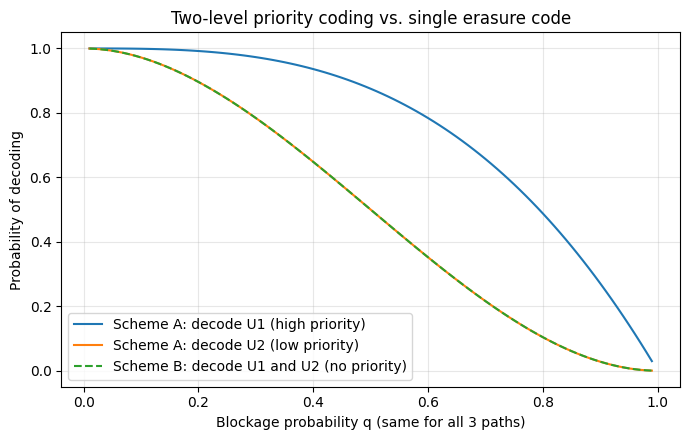

In [3]:
##############################################################
# Title: Two level priority coding simulation
# Fahim Faisal
# CUET 18, EEE
# Lecturer Southern University
##############################################################

# What i have done here ?
# I made this to understand the paper "Two-Level Priority Coding for
# Resilience to Arbitrary Blockage Patterns"

# Groups (from the paper):
#   G1 = only 1 path is ok   -> 100, 010, 001  (we need U1)
#   G2 = 2 or 3 paths are ok -> 110, 101, 011, 111  (we need U1 and U2)
#
# Scheme A = priority coding (like the paper)
#
# Scheme B = normal way, no priority
#
# At the end we compare both schemes.

import itertools
import random

# ------------------------------------------------------------------
# part 1: probability of blockage patterns (Definition 1 in the paper)
# ------------------------------------------------------------------

def pattern_probability(b, q):
    # b is like (1, 0, 1), 1 means path is ok and 0 means blocked
    # q is the list of blockage probabilities for each path
    p = 1.0
    for bi, qi in zip(b, q):
        p *= (1 - qi) if bi == 1 else qi
    return p


def all_patterns(E=3):
    # make all the patterns, but skip 000 (all blocked) because paper skips it
    return [b for b in itertools.product([0, 1], repeat=E) if sum(b) > 0]


def make_groups(E=3):
    # G1 = exactly one path ok, G2 = two or more paths ok
    G1 = [b for b in all_patterns(E) if sum(b) == 1]
    G2 = [b for b in all_patterns(E) if sum(b) >= 2]
    return G1, G2


def theory_probabilities(q, E=3):
    # probability of decoding U1 and U2 from theory (Definition 2)
    G1, G2 = make_groups(E)
    p_g1 = sum(pattern_probability(b, q) for b in G1)
    p_g2 = sum(pattern_probability(b, q) for b in G2)
    return p_g1 + p_g2, p_g2  # P(U1), P(U2)


# ------------------------------------------------------------------
# part 2: encoder and decoder
# I use real bytes so I can check that decoding is correct
# ------------------------------------------------------------------

def encode_scheme_A(u1, u2):
    # u1 is one byte, u2 is a list of 2 bytes
    # returns 3 packets, one for each path
    a, b = u2
    parity = a ^ b
    coded_u2 = [a, b, parity]          # (3,2) code for U2
    return [(u1, coded_u2[i]) for i in range(3)]  # U1 is repeated on every path


def decode_scheme_A(received):
    # received is a dict like {path_number: (u1_byte, coded_u2_byte)}
    if len(received) == 0:
        return None, None

    # for U1 any one packet is enough
    u1 = next(iter(received.values()))[0]

    # for U2 we need at least 2 packets
    if len(received) < 2:
        return u1, None

    c = {i: pkt[1] for i, pkt in received.items()}
    if 0 in c and 1 in c:
        a, b = c[0], c[1]
    elif 0 in c and 2 in c:
        a = c[0]
        b = c[2] ^ a      # parity = a xor b, so b = parity xor a
    else:  # paths 1 and 2
        b = c[1]
        a = c[2] ^ b
    return u1, [a, b]


def encode_scheme_B(u1, u2):
    # baseline: one (3,2) code for everything
    # split the message in two parts, x and y (2 bytes each)
    x = (u1, u2[0])
    y = (u2[1], 0)
    z = (x[0] ^ y[0], x[1] ^ y[1])   # parity packet
    return [x, y, z]


def decode_scheme_B(received):
    # need at least 2 packets, otherwise we get nothing
    if len(received) < 2:
        return None, None
    if 0 in received and 1 in received:
        x, y = received[0], received[1]
    elif 0 in received and 2 in received:
        x = received[0]
        y = (received[2][0] ^ x[0], received[2][1] ^ x[1])
    else:
        y = received[1]
        x = (received[2][0] ^ y[0], received[2][1] ^ y[1])
    return x[0], [x[1], y[0]]


# ------------------------------------------------------------------
# part 3: Monte Carlo simulation
# we run many random trials and count how many times decoding works
# ------------------------------------------------------------------

def simulate(q, trials=200_000, seed=1):
    rng = random.Random(seed)
    stats = {
        "A_U1": 0, "A_U2": 0,
        "B_U1": 0, "B_U2": 0,
        "errors": 0,
    }

    for _ in range(trials):
        # make random data
        u1 = rng.randrange(256)
        u2 = [rng.randrange(256), rng.randrange(256)]

        # each path is ok with probability 1 - q_i
        unblocked = [rng.random() > q[i] for i in range(3)]
        if not any(unblocked):
            # all paths blocked (000), we skip it like the paper
            continue

        # Scheme A
        pkts = encode_scheme_A(u1, u2)
        rec = {i: pkts[i] for i in range(3) if unblocked[i]}
        d1, d2 = decode_scheme_A(rec)
        if d1 is not None:
            if d1 != u1:
                stats["errors"] += 1
            stats["A_U1"] += 1
        if d2 is not None:
            if d2 != u2:
                stats["errors"] += 1
            stats["A_U2"] += 1

        # Scheme B
        pkts = encode_scheme_B(u1, u2)
        rec = {i: pkts[i] for i in range(3) if unblocked[i]}
        d1, d2 = decode_scheme_B(rec)
        if d1 is not None:
            if d1 != u1:
                stats["errors"] += 1
            stats["B_U1"] += 1
        if d2 is not None:
            if d2 != u2:
                stats["errors"] += 1
            stats["B_U2"] += 1

    return stats


def conditional_theory(q):
    # theory probabilities but only for trials where at least one path is ok
    # (so it can be compared with the simulation)
    G1, G2 = make_groups()
    p_g1 = sum(pattern_probability(b, q) for b in G1)
    p_g2 = sum(pattern_probability(b, q) for b in G2)
    total = p_g1 + p_g2  # = 1 - q1*q2*q3
    return {
        "A_U1": 1.0,
        "A_U2": p_g2 / total,
        "B_U1": p_g2 / total,
        "B_U2": p_g2 / total,
        "total": total,
    }


# ------------------------------------------------------------------
# part 4: main
# ------------------------------------------------------------------

def main():
    # blockage probabilities are different for each path (path 1 is worst)
    q = [0.4, 0.2, 0.1]
    trials = 200_000

    print("Blockage probabilities q =", q)
    print("Patterns (1 = unblocked) and their probabilities:")
    G1, G2 = make_groups()
    for name, G in (("G1", G1), ("G2", G2)):
        for b in G:
            print(f"  {name}: {''.join(map(str, b))}  P = {pattern_probability(b, q):.4f}")

    p_u1, p_u2 = theory_probabilities(q)
    print(f"\nTheory (Definition 2, over patterns in G1 u G2):")
    print(f"  P(decode U1) = {p_u1:.4f}")
    print(f"  P(decode U2) = {p_u2:.4f}")

    stats = simulate(q, trials=trials)
    cond = conditional_theory(q)

    print("\nMonte Carlo results (given at least one path is unblocked):")
    # A_U1 is decoded in every valid trial, so it counts the valid trials
    n_valid = stats["A_U1"]
    print(f"  valid trials: {n_valid}")
    print(f"  decoding errors: {stats['errors']}  (should be 0)\n")

    header = f"{'':28s}{'Simulation':>12s}{'Theory':>10s}"
    print("Scheme A: priority coding (U1 with (3,1), U2 with (3,2))")
    print(header)
    print(f"{'  P(decode U1)':28s}{stats['A_U1']/n_valid:12.4f}{cond['A_U1']:10.4f}")
    print(f"{'  P(decode U2)':28s}{stats['A_U2']/n_valid:12.4f}{cond['A_U2']:10.4f}")

    print("\nScheme B: no priority (one (3,2) code for everything)")
    print(header)
    print(f"{'  P(decode U1)':28s}{stats['B_U1']/n_valid:12.4f}{cond['B_U1']:10.4f}")
    print(f"{'  P(decode U2)':28s}{stats['B_U2']/n_valid:12.4f}{cond['B_U2']:10.4f}")

    print("\nTakeaway: with the same total rate per path, Scheme A always delivers the")
    print("high-priority data U1 (as long as one path survives), while Scheme B loses")
    print("U1 whenever only one path is left.")

    # extra: plot for different blockage probabilities (same q for all paths)
    try:
        import matplotlib.pyplot as plt

        qs = [i / 100 for i in range(1, 100)]
        a_u1, a_u2, b_all = [], [], []
        for qq in qs:
            qv = [qq, qq, qq]
            p1, p2 = theory_probabilities(qv)
            a_u1.append(p1)
            a_u2.append(p2)
            b_all.append(p2)  # Scheme B needs >= 2 paths for everything

        plt.figure(figsize=(7, 4.5))
        plt.plot(qs, a_u1, label="Scheme A: decode U1 (high priority)")
        plt.plot(qs, a_u2, label="Scheme A: decode U2 (low priority)")
        plt.plot(qs, b_all, "--", label="Scheme B: decode U1 and U2 (no priority)")
        plt.xlabel("Blockage probability q (same for all 3 paths)")
        plt.ylabel("Probability of decoding")
        plt.title("Two-level priority coding vs. single erasure code")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig("decoding_probability.png", dpi=150)
        print("\nSaved plot: decoding_probability.png")
    except ImportError:
        print("\n(matplotlib not installed, skipping plot. Install with: pip install matplotlib)")


if __name__ == "__main__":
    main()